In [2]:
# Cellule 1 — Imports et setup
import sys
import os

# S'assurer que src/ est accessible
sys.path.append(os.path.abspath(".."))

import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1652.5), np.float64(2338.5), np.float64(-0.5))

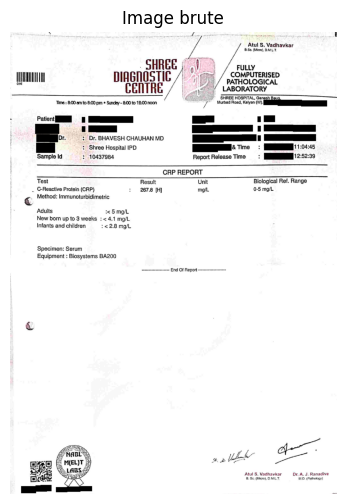

In [ ]:
# Cellule 2 — Charger une image brute
from src.preprocessing.image_loader import load_image

image_path = "../data/raw/test2.png"
image = load_image(image_path)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Image brute")
plt.axis("off")


(np.float64(-0.5), np.float64(1652.5), np.float64(2338.5), np.float64(-0.5))

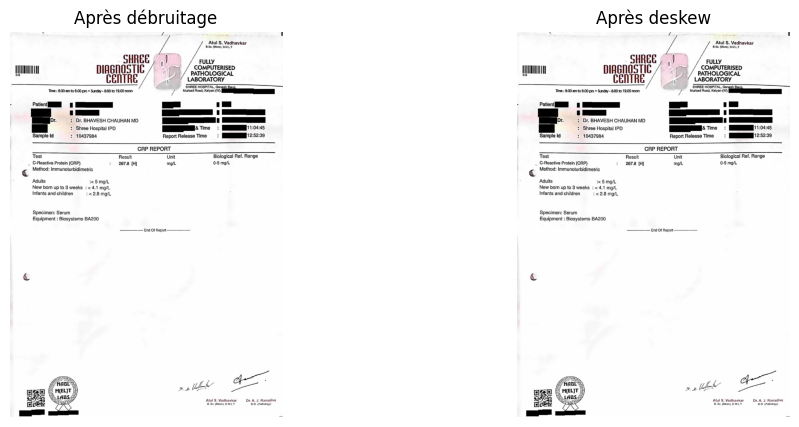

In [4]:
# Cellule 3 — Denoise + Deskew
from src.preprocessing.denoise import denoise_image
from src.preprocessing.deskew import deskew_image

denoised = denoise_image(image)
deskewed = deskew_image(denoised)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
plt.title("Après débruitage")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(deskewed, cv2.COLOR_BGR2RGB))
plt.title("Après deskew")
plt.axis("off")

(np.float64(-0.5), np.float64(2479.5), np.float64(3507.5), np.float64(-0.5))

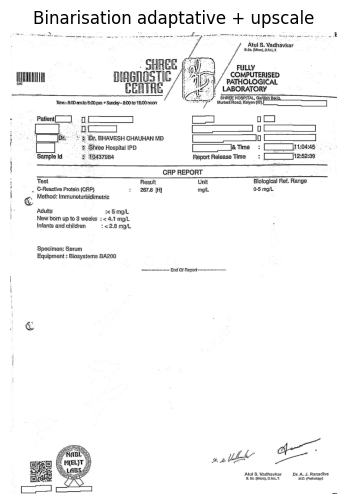

In [ ]:
# Cellule 4 — Binarization + Upscale
from src.preprocessing.binarization import binarize_image

binary = binarize_image(deskewed)

plt.figure(figsize=(10,6))
plt.imshow(binary, cmap="gray")
plt.title("Binarisation adaptative + upscale")
plt.axis("off")

In [ ]:
# Cellule 5 — OCR avec bounding boxes
from src.ocr.easyocr_engine import EasyOCREngine

ocr_engine = EasyOCREngine()
results = ocr_engine.extract_with_boxes(binary)

len(results)

In [ ]:
# Cellule 6 — Visualisation des bounding boxes
import numpy as np
from src.ocr.visualize_boxes import visualize_boxes

visualize_boxes(binary, results)

In [ ]:
# Cellule 7 — Tri spatial des boxes
from src.ocr.box_utils import sort_boxes_top_to_bottom_left_to_right

sorted_results = sort_boxes_top_to_bottom_left_to_right(results)

for r in sorted_results[:10]:
    print(r[1])

In [ ]:
# Cellule 8 — Regroupement par ligne
from src.ocr.box_utils import group_boxes_by_line

lines = group_boxes_by_line(sorted_results)

for line in lines[:5]:
    print([item[1] for item in line["items"]])

In [ ]:
# Cellule 9 — Reconstruction du texte final
from src.ocr.box_utils import reconstruct_text_from_lines

final_text = reconstruct_text_from_lines(lines)
print(final_text)